# LEM VALIDATION

For context to this analysis and graph we refer you to https://docs.google.com/document/d/1MxF69SCqr3JYGorkFOOj0GVdvsZTgOGLjBADEKK1xuY/edit?tab=t.0#heading=h.4518ca4obgqv


In [42]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import matplotlib.ticker as mtick

from datetime import datetime
import os
import sys


current_directory = os.getcwd()
risk_pylibrary_path = current_directory.replace('user_libs/fgv31/RMT_validations','')
repo_path = current_directory.replace('risk_pylibrary/user_libs/fgv31/RMT_validations','')

sys.path.append(repo_path)
sys.path.append(risk_pylibrary_path)

pd.set_option('display.max_columns', None)


import tools.snowflake_db.db_connection as db

In [2]:


sql_all_exposures = """ --sql

select
    report_date as "Report Date",
    counterparty_or_group_id as "Counterparty/Group Id",
    counterparty_or_group_name as "Counterparty/Group Name",
    case is_counterparty_group when true then counterparty_or_group_id else ' ' end as "Counterparty Group Id",
    case is_counterparty_group when false then ifnull(counterparty_or_group_id, ' ') end as "Counterparty Id",
    case is_counterparty_group when true then 'Yes' else 'Unknown' end as "Ultimate Parent?",
    exposure_amount_eur as "Exposure Amount, EUR",
    large_exposure_limit_eur as "Limit (25% of Tier 1), EUR",
    large_exposure_limit_utilisation * 100 as "Limit Utilisation, %"
from
 teams_prd.risk_management_publish.pbl_snapshot__risk_management__lem__all_exposure 
where
    -- Explicitly exclude Deutsche Bundesbank - a central government partner
    ifnull(counterparty_or_group_id, '') <> '529900AQBND3S6YJLY83'
    -- [[and counterparty_identification = {{counterparty_identfication}}]]
order by
    abs(exposure_amount_eur) desc

"""
df_all_exposures = db.run_query(query=sql_all_exposures)
df_all_exposures.head(2)


     ------------------------------------------------------------
               Risk @ Trade Republic Bank GmbH
     ------------------------------------------------------------
      Node: fgv	User: fgv
      Python version 3.12.7 (v3.12.7:0b05ead877f, Sep 30 2024, 23:18:00) [Clang 13.0.0 (clang-1300.0.29.30)]
      pandas: 2.2.3	numpy: 2.2.0
      Kernel started 2024-12-20 12:12
     ------------------------------------------------------------
Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://traderepublic.okta.com/app/snowflake/exk18zobx3kssJFvx417/sso/saml?SAMLRequest=nZJPc9owEMW%2Fikc927IELUSDyZBQCDQ0nuCESW%2FCFkRjW3K0MoZ%2B%2Bsr86aSH5NCbRnq7v6d9O7jel4W3EwakVhEiQYg8oVKdSbWN0FMy8fvIA8tVxgutRIQOAtD1cAC8LCo2qu2rehRvtQDruUYKWPsQodoopjlIYIqXAphN2XK0uGc0CBkHEMY6HDqXZCAd69XaimHcNE3Q

/Users/fgv/Documents/Coding/repos/risk_pylibrary/tools/snowflake_db/db_connection.py:179: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,report date,counterparty/group id,counterparty/group name,counterparty group id,counterparty id,ultimate parent?,"exposure amount, eur","limit (25% of tier 1), eur","limit utilisation, %"
0,2024-08-04,529900G3SW56SHYNPR95,Deutsche Börse AG,529900G3SW56SHYNPR95,None,Yes,3.388090e+08,1.325941e+08,255.523365
1,2024-08-03,529900G3SW56SHYNPR95,Deutsche Börse AG,529900G3SW56SHYNPR95,None,Yes,2.971479e+08,1.325941e+08,224.103309


In [3]:
df_all_date_grouped = df_all_exposures.groupby(['report date'])[['exposure amount, eur']].sum().reset_index()

In [13]:
df_all_date_grouped.head(2)

,report date,"exposure amount, eur"
0,2023-12-01,5.922458e+08
1,2023-12-02,5.893483e+08


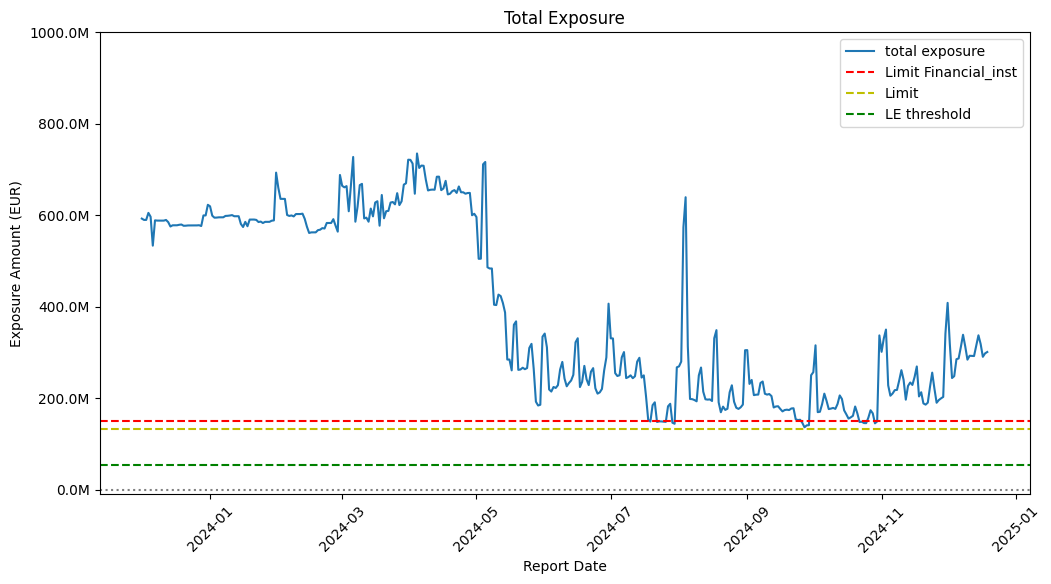

In [20]:


plt.figure(figsize=(12, 6)) 

sns.lineplot(x='report date', y='exposure amount, eur', data=df_all_date_grouped, label='total exposure')

plt.axhline(y=150000000, color='r', linestyle='--', label='Limit Financial_inst')
plt.axhline(y=132000000, color='y', linestyle='--', label='Limit')
plt.axhline(y=53000000, color='g', linestyle='--', label='LE threshold')

# Customize the plot
plt.xlabel('Report Date')
plt.ylabel('Exposure Amount (EUR)')
plt.title('Total Exposure')
plt.axhline(y=0, color='gray', linestyle=':')

# Place the legend below the graph
plt.legend()  # Adjust x and y coordinates as needed

plt.xticks(rotation=45)
plt.ylim(-10000000, 1000000000)

# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()

In [5]:
df_all_exposures_grouped = df_all_exposures.groupby(['report date','counterparty/group name','counterparty group id', 'counterparty/group id', 'ultimate parent?' ])[['exposure amount, eur']].sum().reset_index()

### top 20 ultimate parent exposure 

In [6]:
top_10 = list(set(df_all_exposures_grouped[(df_all_exposures_grouped['exposure amount, eur']> 40000000) & (df_all_exposures_grouped['ultimate parent?']=='Yes')]['counterparty/group name']))
len(top_10)

10

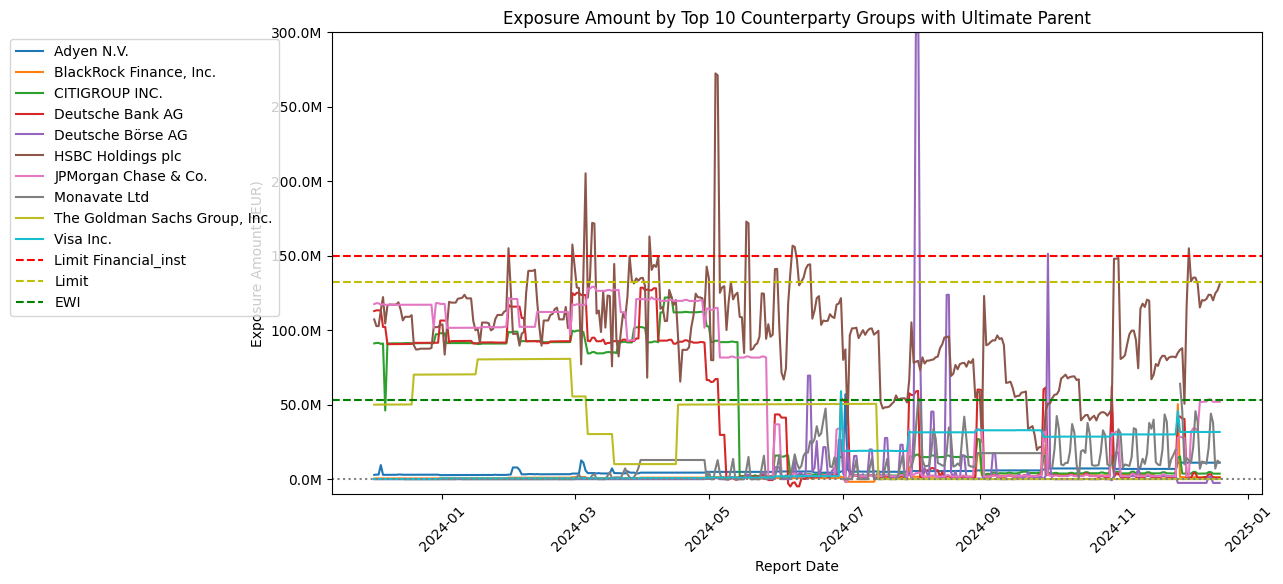

In [7]:

# Assuming your DataFrame is named 'df' 

# Pivot the DataFrame to have 'report date' as index and 'counterparty/group name' as columns
df_pivot = df_all_exposures_grouped[df_all_exposures_grouped['counterparty/group name'].isin(top_10)].pivot(index='report date', columns='counterparty/group name', values='exposure amount, eur')

# Plot the lines
df_pivot.plot(figsize=(12, 6))
plt.axhline(y=150000000, color='r', linestyle='--', label='Limit Financial_inst')
plt.axhline(y=132000000, color='y', linestyle='--', label='Limit')
plt.axhline(y=53000000, color='g', linestyle='--', label='EWI')

# Customize the plot
plt.xlabel('Report Date')
plt.ylabel('Exposure Amount (EUR)')
plt.title('Exposure Amount by Top 10 Counterparty Groups with Ultimate Parent')
plt.axhline(y=0, color='gray', linestyle=':')

# Place the legend below the graph
plt.legend(bbox_to_anchor=(-0.05, 1))  # Adjust x and y coordinates as needed

plt.xticks(rotation=45)
plt.ylim(-10000000, 300000000)

# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()

### top 10 NO parent exposure 


In [8]:
top_10_no_parent = list(set(df_all_exposures_grouped[(df_all_exposures_grouped['exposure amount, eur']> 100000) & (df_all_exposures_grouped['ultimate parent?']!='Yes')]['counterparty/group name']))
len(top_10_no_parent)

11

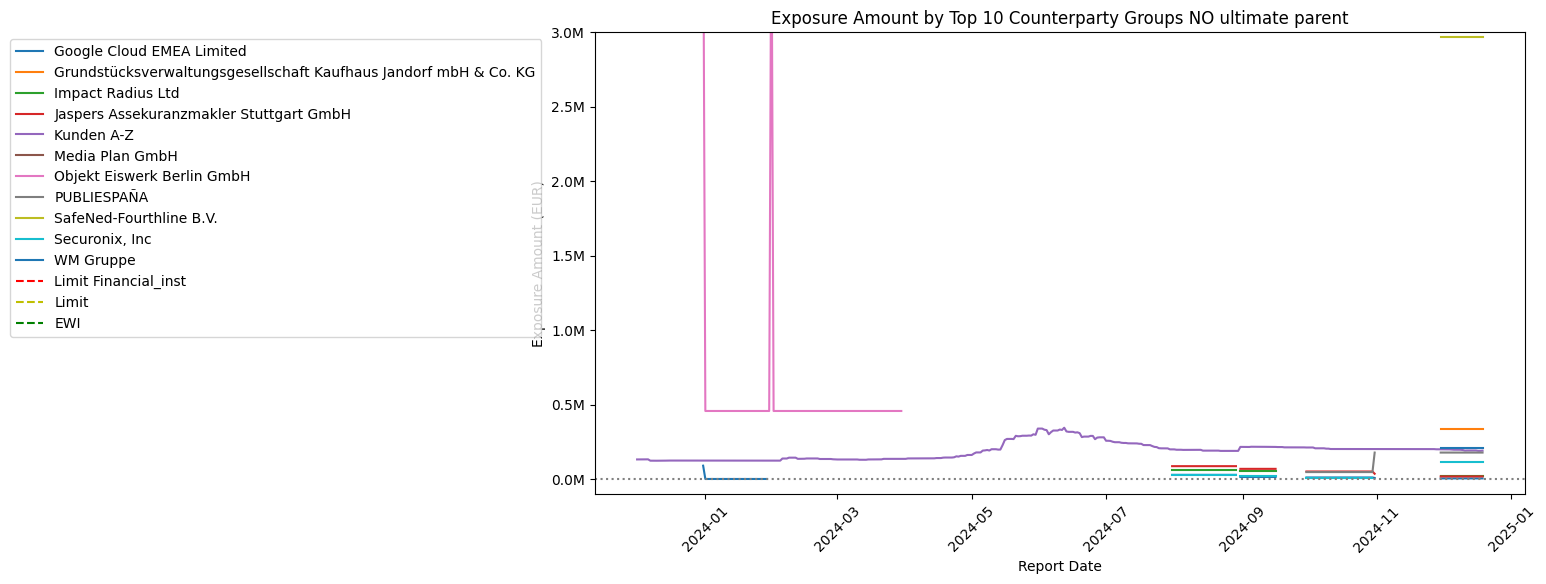

In [9]:

# Assuming your DataFrame is named 'df' 

# Pivot the DataFrame to have 'report date' as index and 'counterparty/group name' as columns
df_pivot = df_all_exposures_grouped[df_all_exposures_grouped['counterparty/group name'].isin(top_10_no_parent)].pivot(index='report date', columns='counterparty/group name', values='exposure amount, eur')

# Plot the lines
df_pivot.plot(figsize=(12, 6))
plt.axhline(y=150000000, color='r', linestyle='--', label='Limit Financial_inst')
plt.axhline(y=132000000, color='y', linestyle='--', label='Limit')
plt.axhline(y=53000000, color='g', linestyle='--', label='EWI')
plt.axhline(y=0, color='gray', linestyle=':')

# Customize the plot
plt.xlabel('Report Date')
plt.ylabel('Exposure Amount (EUR)')
plt.title('Exposure Amount by Top 10 Counterparty Groups NO ultimate parent')

# Place the legend below the graph
plt.legend(bbox_to_anchor=(-0.05, 1))  # Adjust x and y coordinates as needed

plt.xticks(rotation=45)
plt.ylim(-100000, 3000000)

# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()

### negative exposures 

In [10]:
top_10_negative = list(set(df_all_exposures_grouped[(df_all_exposures_grouped['exposure amount, eur']< -10000)]['counterparty/group name']))
len(top_10_negative)

20

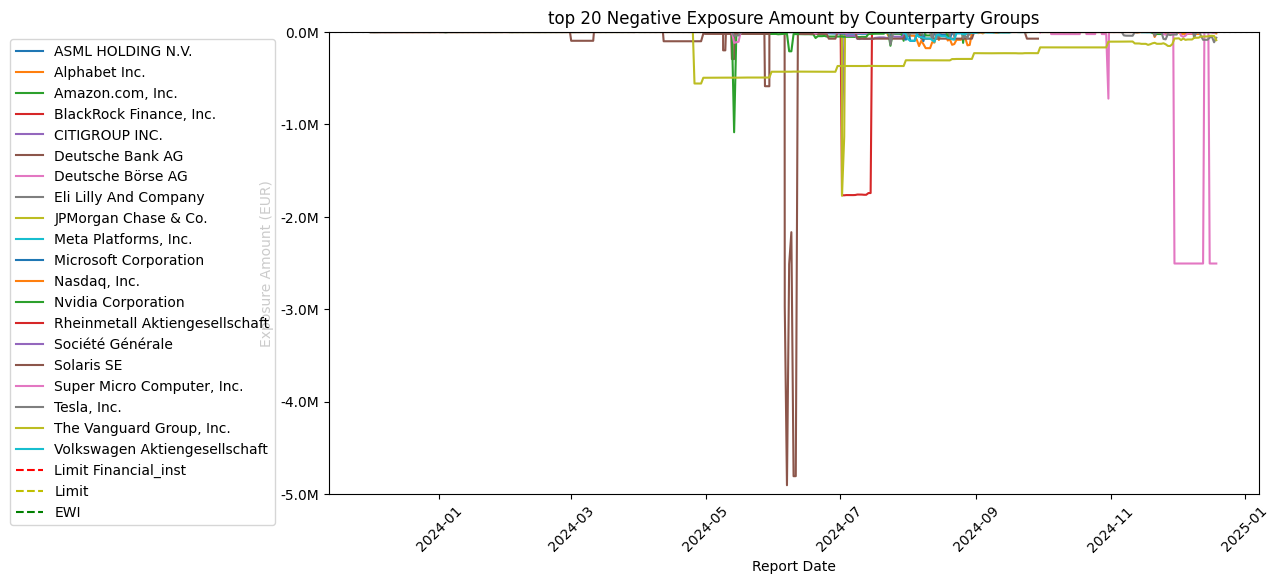

In [11]:
# Assuming your DataFrame is named 'df' 

# Pivot the DataFrame to have 'report date' as index and 'counterparty/group name' as columns
df_pivot = df_all_exposures_grouped[df_all_exposures_grouped['counterparty/group name'].isin(top_10_negative)].pivot(index='report date', columns='counterparty/group name', values='exposure amount, eur')

# Plot the lines
df_pivot.plot(figsize=(12, 6))
plt.axhline(y=150000000, color='r', linestyle='--', label='Limit Financial_inst')
plt.axhline(y=132000000, color='y', linestyle='--', label='Limit')
plt.axhline(y=53000000, color='g', linestyle='--', label='EWI')
plt.axhline(y=0, color='gray', linestyle=':')

# Customize the plot
plt.xlabel('Report Date')
plt.ylabel('Exposure Amount (EUR)')
plt.title('top 20 Negative Exposure Amount by Counterparty Groups')

# Place the legend below the graph
plt.legend(bbox_to_anchor=(-0.05, 1))  # Adjust x and y coordinates as needed

plt.xticks(rotation=45)
plt.ylim(-5000000, 000000)


# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()

# Drilling down 

In [43]:
sql_breakdown_exposures = """ --sql

with data__counterparty_name as (
    select
        _check__source,
        _check__file_row_number,
        _check__file_last_modified,
        _check__snapshot_dt,

        counterparty_id,
        counterparty_name
    from
        teams_prd.risk_management_transform.trf_curr__risk_management__lem__counterparty
    qualify
        -- Deduplicate to only one row per Counterparty
        row_number() over (
            partition by
                counterparty_id
            order by
                -- First, prioritise REF_Counterparty_SAP > REF_Counterparty over LEM Counterparty Remapping
                case _check__source
                    when 'ref_counterparty' then 1
                    when 'treasury_bonds' then 2
                    when 'lem_counterparty_remapping' then 3
                    else 4
                end,
                -- Second, prioritise the earliest row
                _check__file_row_number
        ) = 1
),
/* Intermediate CTE: Union of all sources */
data__union as (
    select
        'Booking Engine' as _metadata__source,
        data__booking_engine.report_date,
        null::varchar as counterparty_id,
        data__booking_engine.sap_gl_account as gl_account,
        null::varchar as instrument_id,
        data__booking_engine.is_exposure_relevant,
        sum(data__booking_engine.exposure_amount_eur) as exposure_amount_eur,
        sum(sum(data__booking_engine.exposure_amount_eur)) over (
            partition by
                data__booking_engine.report_date,
                data__booking_engine.sap_gl_account
         ) as exposure_amount_eur_gl_account,
        data__booking_engine.exposure_currency_code,
        sum(data__booking_engine.exposure_amount_curr) as exposure_amount_curr
    from
        teams_prd.risk_management_transform.trf_snapshot__risk_management__lem__booking_engine as data__booking_engine
    where
        -- Exclude GL Accounts that are present in the Manual Subledger
        not exists (
            select
                *
            from
                teams_prd.risk_management_transform.trf_snapshot__risk_management__lem__manual_subledger
            where
                report_date = data__booking_engine.report_date
                and gl_account = data__booking_engine.sap_gl_account
        )
    group by
        all
    having
        -- Filter out zero amounts
        (
            abs(ifnull(sum(exposure_amount_eur), 0)) >= 0.01
            or abs(ifnull(sum(exposure_amount_curr), 0)) >= 0.01
        )

    union all

    select
        'SAP Line Items' as _metadata__source,
        data__line_item.report_date,
        ifnull(
            data__ref_counterparty.counterparty_id,
            data__line_item.counterparty_id_sap
        ) as counterparty_id,
        data__line_item.gl_account,
        null::varchar as instrument_id,
        data__line_item.is_exposure_relevant,
        sum(data__line_item.exposure_amount_eur) as exposure_amount_eur,
        sum(sum(data__line_item.exposure_amount_eur)) over (
            partition by
                data__line_item.report_date,
                data__line_item.gl_account
        ) as exposure_amount_eur_gl_account,
        data__line_item.exposure_currency_code,
        sum(data__line_item.exposure_amount_curr) as exposure_amount_curr
    from
        teams_prd.risk_management_transform.trf_snapshot__risk_management__lem__sap_line_item as data__line_item
        -- Source for Counterparty Id SAP to Counterparty Id mapping
        left outer join teams_prd.risk_management_transform.trf_curr__risk_management__lem__counterparty as data__ref_counterparty on
            data__line_item.counterparty_id_sap = data__ref_counterparty.counterparty_id_sap
    where
        -- Exclude GL Accounts that are present in the Manual Subledger
        not exists (
            select
                *
            from
                teams_prd.risk_management_transform.trf_snapshot__risk_management__lem__manual_subledger
            where
                report_date = data__line_item.report_date
                and gl_account = data__line_item.gl_account
        )
    group by
        all
    having
        -- Filter out zero amounts
        (
            abs(ifnull(sum(exposure_amount_eur), 0)) >= 0.01
            or abs(ifnull(sum(exposure_amount_curr), 0)) >= 0.01
        )

    union all

    -- Implement a merge of non-matured items with a delta of SAP Line Item balance
    select
        'Manual Subledger' as _metadata__source,
        data__ms.report_date,
        -- Prefer the remapped Counterparty Id over the original one
        ifnull(
            data__counterparty_remapping.counterparty_id_remapped,
            data__ms.counterparty_id
        ) as counterparty_id,
        data__ms.gl_account,
        null::varchar as instrument_id,
        data__ms.is_exposure_relevant,
        sum(data__ms.exposure_amount_eur) as exposure_amount_eur,
        sum(sum(data__ms.exposure_amount_eur)) over (
            partition by
                data__ms.report_date,
                data__ms.gl_account
        ) as exposure_amount_eur_gl_account,
        data__ms.exposure_currency_code,
        sum(data__ms.exposure_amount_curr) as exposure_amount_curr
    from
        teams_prd.risk_management_transform.trf_snapshot__risk_management__lem__manual_subledger as data__ms
        -- Source for Counterparty Id remapping. Here used to replace outdated identifiers
        left outer join teams_prd.risk_management_staging.stg_curr__risk_management__lem__counterparty_remapping as data__counterparty_remapping on
            data__ms.counterparty_id = data__counterparty_remapping.counterparty_id
    group by
        all
    having
        -- Filter out zero amounts
        (
            abs(ifnull(sum(data__ms.exposure_amount_eur), 0)) >= 0.01
            or abs(ifnull(sum(data__ms.exposure_amount_curr), 0)) >= 0.01
        )

    union all

    select
        'Trading Book' as _metadata__source,
        report_date,
        counterparty_id,
        null::varchar as gl_account,
        instrument_id,
        true as is_exposure_relevant,
        sum(exposure_amount_eur) as exposure_amount_eur,
        null::double as exposure_amount_eur_gl_account,
        exposure_currency_code,
        sum(exposure_amount_curr) as exposure_amount_curr
    from
        teams_prd.risk_management_transform.trf_snapshot__risk_management__lem__trading_book
    group by
        all
    having
        -- Filter out zero amounts
        (
            abs(ifnull(sum(exposure_amount_eur), 0)) >= 0.01
            or abs(ifnull(sum(exposure_amount_curr), 0)) >= 0.01
        )

    union all

    select
        'Treasury Bonds' as _metadata__source,
        report_date,
        counterparty_id,
        null::varchar as gl_account,
        instrument_id,
        true as is_exposure_relevant,
        sum(exposure_amount_eur) as exposure_amount_eur,
        null::double as exposure_amount_eur_gl_account,
        exposure_currency_code,
        sum(exposure_amount_curr) as exposure_amount_curr,
    from
        teams_prd.risk_management_transform.trf_snapshot__risk_management__lem__treasury_bond
    group by
        all
    having
        -- Filter out zero amounts
        (
            abs(ifnull(sum(exposure_amount_eur), 0)) >= 0.01
            or abs(ifnull(sum(exposure_amount_curr), 0)) >= 0.01
        )

    union all

    select
        'Treasury Deposits' as _metadata__source,
        report_date,
        counterparty_id,
        null::varchar as gl_account,
        instrument_id,
        true as is_exposure_relevant,
        sum(exposure_amount_eur) as exposure_amount_eur,
        null::double as exposure_amount_eur_gl_account,
        exposure_currency_code,
        sum(exposure_amount_curr) as exposure_amount_curr
    from
        teams_prd.risk_management_transform.trf_snapshot__risk_management__lem__treasury_deposit
    group by
        all
    having
        -- Filter out zero amounts
        (
            abs(ifnull(sum(exposure_amount_eur), 0)) >= 0.01
            or abs(ifnull(sum(exposure_amount_curr), 0)) >= 0.01
        )
),
/* Helper CTE: Counterparty Id by GL Account from the latest import */
data__gl_account_counterparty as (
    select
        min(_check__file_row_number) as _check__file_row_number,
        max(_check__file_last_modified) as _check__file_last_modified,

        max(_check__snapshot_date) as _check__snapshot_date,

        sap_gl_account as gl_account,

        max(
            case
                when flipping_asset_liability is null or flipping_asset_liability ilike 'Asset'
                then counterparty_id
            end
        ) as counterparty_id_asset,
        max(
            case
                when flipping_asset_liability is null or flipping_asset_liability ilike 'Liability'
                then counterparty_id
            end
        ) as counterparty_id_liability
    from
        teams_prd.risk_management_staging.stg_curr__risk_management__lem__gl_account_counterparty
    group by
        gl_account
),
/* Helper CTE: List of Flipping Accounts from the latest import */
data__flipping_account as (
    select
        snapshot_dt,

        g_l_account as gl_account
    from
        teams_prd.regulatory_reporting_source.src_snapshot__regulatory_reporting__flipping_accounts
    qualify
        dense_rank() over (order by snapshot_dt desc) = 1
),
/* Intermediate CTE: Enrichment of union of all sources with Counterparty Id by GL Account */
data__union_enriched as (
    select
        _metadata__source,
        data__union.report_date,
        ifnull(
            data__union.counterparty_id,
            case sign(data__union.exposure_amount_eur_gl_account)
                when
                    -1
                then
                    data__gl_account_counterparty.counterparty_id_liability
                else
                    data__gl_account_counterparty.counterparty_id_asset
            end
        ) as counterparty_id,
        data__union.gl_account,
        data__union.instrument_id,
        data__union.is_exposure_relevant,
        data__union.exposure_amount_eur,
        data__union.exposure_currency_code,
        data__union.exposure_amount_curr
    from
        data__union
        -- Source for GL Account to Counterparty Id mapping
        left outer join data__gl_account_counterparty on
            data__union.gl_account = data__gl_account_counterparty.gl_account
        -- Source for Flipping Accounts
        left outer join data__flipping_account on
            data__union.gl_account = data__flipping_account.gl_account
    where
        -- If the GL Account is flipping, take it only if it is positive (Asset)
        (
            data__flipping_account.gl_account is null
            or sign(data__union.exposure_amount_eur_gl_account) = 1
        )
)
select
    current_timestamp() as _metadata__loaded_ts,

    data__counterparty_name._check__source as _check__counterparty__source,
    data__counterparty_name._check__file_row_number as _check__counterparty__file_row_number,
    data__counterparty_name._check__file_last_modified as _check__counterparty__file_last_modified,
    data__counterparty_name._check__snapshot_dt as _check__counterparty__snapshot_dt,

    data__counterparty_group._check__source as _check__counterparty_group__source,
    data__counterparty_group._check__file_row_number as _check__counterparty_group__file_row_number,
    data__counterparty_group._check__file_last_modified as _check__counterparty_group__file_last_modified,
    data__counterparty_group._check__snapshot_dt as _check__counterparty_group__snapshot_dt,

    data__union_enriched._metadata__source,

    data__union_enriched.report_date,

    data__union_enriched.counterparty_id,
    data__counterparty_name.counterparty_name,

    data__counterparty_group.counterparty_group_id,
    data__counterparty_group_name.counterparty_name as counterparty_group_name,

    data__union_enriched.gl_account,
    data__gl_account_name.gl_account_name,

    data__union_enriched.instrument_id,

    data__union_enriched.is_exposure_relevant,

    data__union_enriched.exposure_amount_eur,
    data__union_enriched.exposure_currency_code,
    data__union_enriched.exposure_amount_curr,

    concat(
        to_char(data__union_enriched.report_date, 'yyyymmdd'),
        '-',
        data__union_enriched._metadata__source,
        '-',
        ifnull(data__union_enriched.counterparty_id, ''),
        '-',
        ifnull(data__union_enriched.gl_account, ''),
        '-',
        ifnull(data__union_enriched.instrument_id, ''),
        '-',
        ifnull(data__union_enriched.exposure_currency_code, '')
    ) as surrogate_key,

    sum(data__union_enriched.exposure_amount_eur) over (
        partition by
            data__union_enriched.report_date,
            data__counterparty_group.counterparty_group_id
    ) as exposure_amount_eur_counterparty_group,
    count(*) over (
        partition by
            data__union_enriched.report_date,
            data__counterparty_group.counterparty_group_id
    ) as count_exposures_counterparty_group,
    sum(data__union_enriched.exposure_amount_eur) over (
        partition by
            data__union_enriched.report_date,
            data__counterparty_group.counterparty_group_id,
            data__union_enriched.counterparty_id
    ) as exposure_amount_eur_counterparty,
    count(*) over (
        partition by
            data__union_enriched.report_date,
            data__counterparty_group.counterparty_group_id,
            data__union_enriched.counterparty_id
    ) as count_exposures_counterparty
from
    -- Source for exposures
    data__union_enriched
    -- Source for Counterparty Name
    left outer join data__counterparty_name on
        data__union_enriched.counterparty_id = data__counterparty_name.counterparty_id
    -- Source for Counterparty Group
    left outer join teams_prd.risk_management_transform.trf_curr__risk_management__lem__counterparty_group as data__counterparty_group on
        data__union_enriched.counterparty_id = data__counterparty_group.counterparty_id
    -- Source for Counterparty Group Name
    left outer join data__counterparty_name as data__counterparty_group_name on
        data__counterparty_group.counterparty_group_id = data__counterparty_group_name.counterparty_id
    -- Source for GL Account Name
    left outer join teams_prd.risk_management_staging.stg_curr__risk_management__lem__gl_account_name as data__gl_account_name on
        data__union_enriched.gl_account = data__gl_account_name.gl_account
order by
    data__union_enriched.report_date desc,
    exposure_amount_eur_counterparty_group desc,
    exposure_amount_eur_counterparty desc,
    data__union_enriched.counterparty_id,
    data__counterparty_name.counterparty_name,
    abs(data__union_enriched.exposure_amount_eur) desc,
    data__union_enriched.gl_account,
    data__union_enriched.instrument_id,
    data__union_enriched.exposure_currency_code 

"""
df_breakdown_exposures = db.run_query(query=sql_breakdown_exposures)

df_breakdown_exposures.head(2)

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://traderepublic.okta.com/app/snowflake/exk18zobx3kssJFvx417/sso/saml?SAMLRequest=nZJbc9owEIX%2Fikd9tmUZJ1ANkOFSUjpJSrh0Jn0T9gIKtmS0Mib59ZW5dJKH5CFvGunsfkd7tn1zyDNvDwalVh3CgpB4oBKdSrXukMV85LeIh1aoVGRaQYe8AJKbbhtFnhW8V9qNmsKuBLSea6SQ1w8dUhrFtUCJXIkckNuEz3r3dzwKQi4QwViHI%2BeSFKVjbawtOKVVVQVVI9BmTaMwDGn4nTpVLflG3iCKzxmF0VYnOruUHNyfPkAwGsY1wikcYXIu7Et1GsFnlOVJhPznfD7xJ79nc%2BL1Lr8baIVlDmYGZi8TWEzvTgbQObi9v241ms0ASj8BZY3IfBag0tUqE1tIdF6U1jUO3ImuIKWZXks3rvGwQ4qtTH%2FYx2rfb141N3r9IJbmeXe7fJpK%2Faxe%2ByralNdmwXaDhYifHhPi%2FbmEG9XhjhFLGKs6Uuuuwij2WeRH4Zw1%2BFWLx3EQsfAv8YYuUqmEPVZefDunKRgoymUmk0BvrThaFEVB%2F7uncNiy1qteHhpbxF%2Bj%2FSFmTYqoaZ0bOa0OP9ow3S8MpE3fNjgv4oPLZjycaGfrxRtpkwv7cXQsYMcbmfqro5RDLmTWS1MDiC7CLNPVwICwbt%2BtKYHQ7on6fuO7%2FwA%3D&Rel

/Users/fgv/Documents/Coding/repos/risk_pylibrary/tools/snowflake_db/db_connection.py:179: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,_metadata__loaded_ts,_check__counterparty__source,_check__counterparty__file_row_number,_check__counterparty__file_last_modified,_check__counterparty__snapshot_dt,_check__counterparty_group__source,_check__counterparty_group__file_row_number,_check__counterparty_group__file_last_modified,_check__counterparty_group__snapshot_dt,_metadata__source,report_date,counterparty_id,counterparty_name,counterparty_group_id,counterparty_group_name,gl_account,gl_account_name,instrument_id,is_exposure_relevant,exposure_amount_eur,exposure_currency_code,exposure_amount_curr,surrogate_key,exposure_amount_eur_counterparty_group,count_exposures_counterparty_group,exposure_amount_eur_counterparty,count_exposures_counterparty
0,2024-12-20 13:58:46.597000+00:00,ref_counterparty,786.0,2024-12-20 12:28:48,2024-12-20,ref_party_groups,1009.0,2024-12-20 12:18:01,2024-12-20,SAP Line Items,2024-12-19,529900SEOICVR2VM6Y05,Deutsche Bundesbank,529900AQBND3S6YJLY83,Bundesrepublik Deutschland,10102100,Bundesbank Main Cash Account,None,None,5.282796e+08,EUR,5.282796e+08,20241219-SAP Line Items-529900SEOICVR2VM6Y05-1...,5.284244e+08,46,5.284243e+08,3
1,2024-12-20 13:58:46.597000+00:00,ref_counterparty,786.0,2024-12-20 12:28:48,2024-12-20,ref_party_groups,1009.0,2024-12-20 12:18:01,2024-12-20,SAP Line Items,2024-12-19,529900SEOICVR2VM6Y05,Deutsche Bundesbank,529900AQBND3S6YJLY83,Bundesrepublik Deutschland,10399010,All interest receivables from Banks,None,None,1.437788e+05,EUR,1.437788e+05,20241219-SAP Line Items-529900SEOICVR2VM6Y05-1...,5.284244e+08,46,5.284243e+08,3


### Bundesbank Balance 

In [54]:
df_breakdown_exposures_grouped_bundesbank = df_breakdown_exposures[df_breakdown_exposures['counterparty_name']=='Deutsche Bundesbank'].groupby(['report_date', '_metadata__source'])[['exposure_amount_eur']].sum().reset_index()

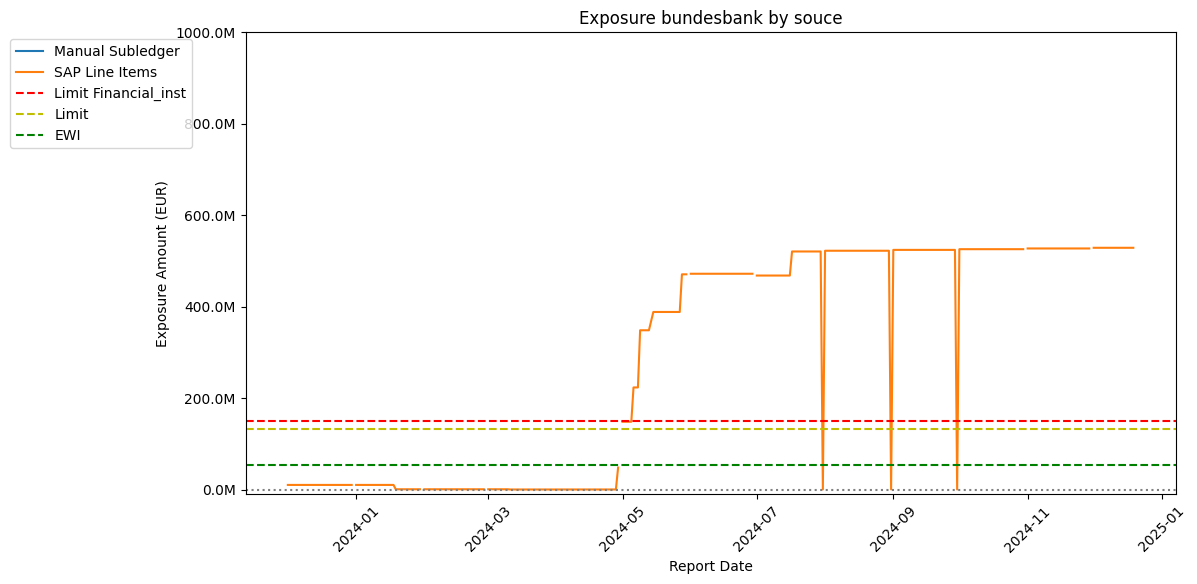

In [55]:

# Assuming your DataFrame is named 'df' 

# Pivot the DataFrame to have 'report date' as index and 'counterparty/group name' as columns
df_pivot = df_breakdown_exposures_grouped_bundesbank.pivot(index='report_date', columns='_metadata__source', values='exposure_amount_eur')

# Plot the lines
df_pivot.plot(figsize=(12, 6))
plt.axhline(y=150000000, color='r', linestyle='--', label='Limit Financial_inst')
plt.axhline(y=132000000, color='y', linestyle='--', label='Limit')
plt.axhline(y=53000000, color='g', linestyle='--', label='EWI')

# Customize the plot
plt.xlabel('Report Date')
plt.ylabel('Exposure Amount (EUR)')
plt.title('Exposure bundesbank by souce')
plt.axhline(y=0, color='gray', linestyle=':')

# Place the legend below the graph
plt.legend(bbox_to_anchor=(-0.05, 1))  # Adjust x and y coordinates as needed

plt.xticks(rotation=45)
plt.ylim(-10000000, 1000000000)

# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()

### Others

In [56]:
df_breakdown_exposures_grouped = df_breakdown_exposures[df_breakdown_exposures['counterparty_name']!='Deutsche Bundesbank'].groupby(['report_date', '_metadata__source'])[['exposure_amount_eur']].sum().reset_index()

In [57]:
df_breakdown_exposures_grouped.head()

,report_date,_metadata__source,exposure_amount_eur
0,2023-12-01,Booking Engine,1.317976e+07
1,2023-12-01,Manual Subledger,1.339054e+07
2,2023-12-01,SAP Line Items,3.326402e+08
3,2023-12-01,Trading Book,3.696450e+06
4,2023-12-01,Treasury Bonds,8.932363e+07


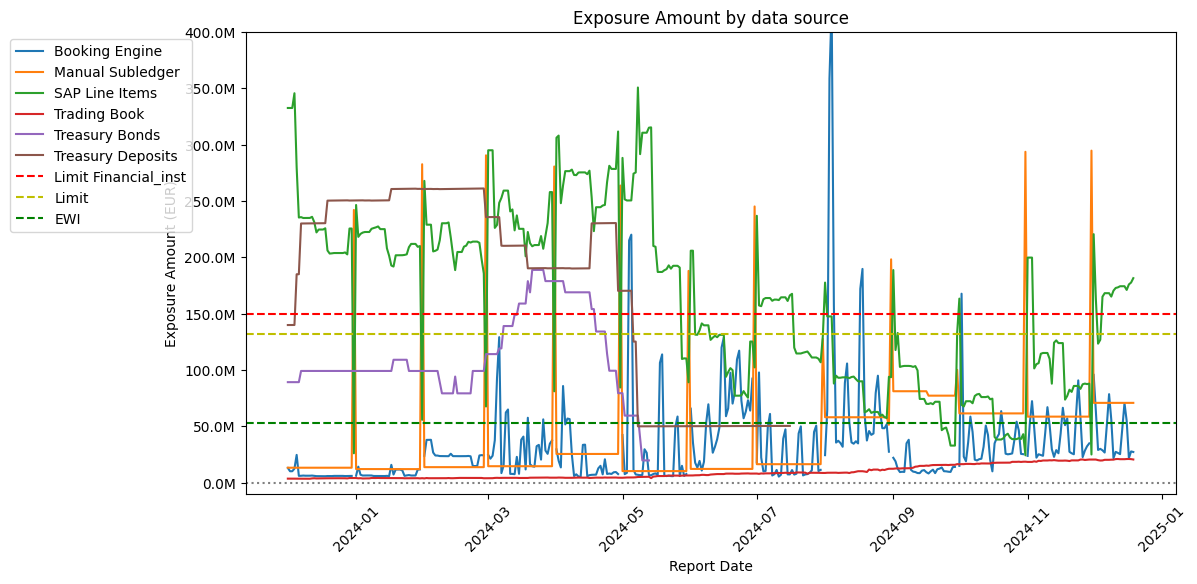

In [66]:

# Assuming your DataFrame is named 'df' 

# Pivot the DataFrame to have 'report date' as index and 'counterparty/group name' as columns
df_pivot = df_breakdown_exposures_grouped.pivot(index='report_date', columns='_metadata__source', values='exposure_amount_eur')

# Plot the lines
df_pivot.plot(figsize=(12, 6))
plt.axhline(y=150000000, color='r', linestyle='--', label='Limit Financial_inst')
plt.axhline(y=132000000, color='y', linestyle='--', label='Limit')
plt.axhline(y=53000000, color='g', linestyle='--', label='EWI')

# Customize the plot
plt.xlabel('Report Date')
plt.ylabel('Exposure Amount (EUR)')
plt.title('Exposure Amount by data source')
plt.axhline(y=0, color='gray', linestyle=':')

# Place the legend below the graph
plt.legend(bbox_to_anchor=(-0.05, 1))  # Adjust x and y coordinates as needed

plt.xticks(rotation=45)
plt.ylim(-10000000, 400000000)

# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()

#### only negative befor netting out 

In [60]:
df_breakdown_exposures_negative_amount = df_breakdown_exposures[df_breakdown_exposures['exposure_amount_eur'] < 0]

df_breakdown_exposures_grouped_negative = df_breakdown_exposures_negative_amount[df_breakdown_exposures_negative_amount['counterparty_name']!='Deutsche Bundesbank'].groupby(['report_date', '_metadata__source'])[['exposure_amount_eur']].sum().reset_index()

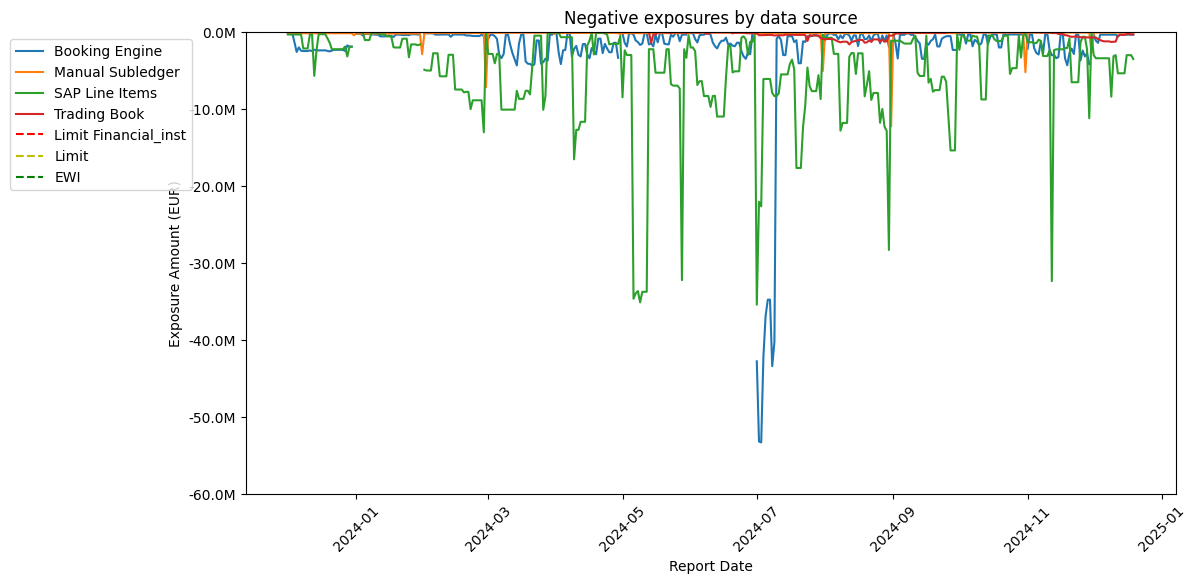

In [67]:

# Assuming your DataFrame is named 'df' 

# Pivot the DataFrame to have 'report date' as index and 'counterparty/group name' as columns
df_pivot = df_breakdown_exposures_grouped_negative.pivot(index='report_date', columns='_metadata__source', values='exposure_amount_eur')

# Plot the lines
df_pivot.plot(figsize=(12, 6))
plt.axhline(y=150000000, color='r', linestyle='--', label='Limit Financial_inst')
plt.axhline(y=132000000, color='y', linestyle='--', label='Limit')
plt.axhline(y=53000000, color='g', linestyle='--', label='EWI')

# Customize the plot
plt.xlabel('Report Date')
plt.ylabel('Exposure Amount (EUR)')
plt.title('Negative exposures by data source')
plt.axhline(y=0, color='gray', linestyle=':')

# Place the legend below the graph
plt.legend(bbox_to_anchor=(-0.05, 1))  # Adjust x and y coordinates as needed

plt.xticks(rotation=45)
plt.ylim(-60000000, 0000000)

# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()